# 04 – XGBoost: Ensemblemodell med Boosting

## Vad är XGBoost?
Tänk dig att du tränar för ett prov och gör fel på frågorna.
Nästa gång du tränar – fokuserar du *extra mycket* på just de frågorna du hade fel på.
Det är precis vad **XGBoost** gör!

XGBoost bygger träd **ett i taget**, och varje nytt träd försöker rätta till
de misstag som det förra trädet gjorde.
Det kallas **Boosting** – vi boostar (förstärker) modellen steg för steg.

## Boosting vs Bagging – vad är skillnaden?

| | Random Forest (Bagging) | XGBoost (Boosting) |
|--|------------------------|-------------------|
| Träd byggs | Parallellt, oberoende | Sekventiellt, ett i taget |
| Varje träd lär sig | Från slumpmässig data | Från föregående träds misstag |
| Fokus | Minska varians (overfitting) | Minska bias (underfitting) |
| Hastighet | Snabb att träna | Kan vara långsammare |
| Ofta bättre på | Brusig data | Tabulär/strukturerad data |

## Vad gör vi i denna notebook?
1. Laddar och förbereder datan (samma pipeline som tidigare)
2. Tränar ett **standard XGBoost** (snabb referens)
3. Finjusterar hyperparametrar med **RandomizedSearchCV**
4. Utvärderar med F1, ROC-AUC och Recall
5. Plottar Feature Importance och Permutation Importance
6. Sparar resultat till `outputs/`

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os

os.chdir("..")          # sätt projektroten som arbetskatalog
sys.path.append(".")    # så att Python hittar src/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_raw, clean_and_encode, split_and_scale
from src.model_training import train_xgboost, tune_xgboost
from src.evaluation import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
    plot_permutation_importance,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

print(f"✅ Arbetskatalog: {os.getcwd()}")
print("✅ Allt importerat och redo!")

✅ Arbetskatalog: c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml
✅ Allt importerat och redo!


## Steg 1 – Ladda och förbered datan

Samma pipeline som i notebook 02 och 03 – vi håller allt konsekvent
så att vi kan jämföra modellerna rättvist på exakt samma data.

In [2]:
# ── Ladda färdigbearbetad data ─────────────────────────────────────────────────
import pandas as pd

CLEAN_PATH = "data/attrition_clean.csv"

df_clean = pd.read_csv(CLEAN_PATH)
X_train, X_test, y_train, y_test = split_and_scale(df_clean)

print(f"✅ Laddade rensad data från : {CLEAN_PATH}")
print(f"   Träningsdata : {X_train.shape[0]} rader, {X_train.shape[1]} kolumner")
print(f"   Testdata     : {X_test.shape[0]} rader, {X_test.shape[1]} kolumner")
print(f"   Attrition Yes i träning  : {y_train.sum()} ({y_train.mean():.1%})")
print(f"   Attrition Yes i test     : {y_test.sum()} ({y_test.mean():.1%})")

[data_processing] Split: 1,176 train / 294 test (stratified, test_size=0.2)
✅ Laddade rensad data från : data/attrition_clean.csv
   Träningsdata : 1176 rader, 44 kolumner
   Testdata     : 294 rader, 44 kolumner
   Attrition Yes i träning  : 190 (16.2%)
   Attrition Yes i test     : 47 (16.0%)


## Vad ser vi? – Datan är redo

Vi har laddat den **redan rensade** datan direkt från `attrition_clean.csv`
och delat upp den i tränings- och testset.

| | Antal rader | Kolumner |
|--|------------|---------|
| Träningsdata | 1 176 | 44 |
| Testdata | 294 | 44 |

### Klassobalansen finns kvar – och det är meningen
Både tränings- och testset har ~16 % Attrition = Yes.
Det kallas **stratifierad split** – vi ser till att fördelningen
Yes/No bevaras i båda delar, annars kan modellen råka träna på
för lite eller för mycket av den sällsynta klassen.

XGBoost hanterar obalansen via parametern `scale_pos_weight` –
den räknar automatiskt ut hur mycket mer vikt de positiva fallen ska få.

## Steg 2 – Träna ett standard XGBoost

Innan vi finjusterar tränar vi ett **standard XGBoost** med defaultvärden.
Det ger oss en snabb referenspunkt – precis som vi gjorde med Random Forest.

`scale_pos_weight` räknas ut automatiskt från träningsdatan:
- ~984 anställda stannar (No)
- ~190 anställda slutar (Yes)
- Viktfaktor ≈ 984 / 190 ≈ **5.2** – Yes-fallen väger alltså 5× mer!

In [3]:
# ── Träna standard XGBoost ─────────────────────────────────────────────────────
xgb_default = train_xgboost(X_train, y_train)

results_default = evaluate_model(
    xgb_default,
    X_test,
    y_test,
    model_name="xgboost_default",
)

[model_training] Training XGBoost with params: {'n_estimators': 200, 'scale_pos_weight': np.float64(5.189473684210526), 'eval_metric': 'logloss', 'n_jobs': -1, 'random_state': 42}
[model_training] XGBoost training complete.
[evaluation] xgboost_default | F1: 0.4384 | ROC-AUC: 0.7462
[evaluation] Results saved to: outputs/results\xgboost_default.json


## Vad ser vi? – Standard XGBoost

| Modell | F1-score | ROC-AUC |
|--------|---------|---------|
| Decision Tree | 0.2667 | 0.6473 |
| Random Forest (tunad) | 0.3014 | 0.7659 |
| **XGBoost (standard)** | **0.4384** | **0.7462** |

### Wow – redan utan tuning slår XGBoost den tunade Random Forest på F1!

- **F1 = 0.4384** – nästan 50% bättre än tunad Random Forest (0.3014)
- **ROC-AUC = 0.7462** – något lägre än RF, men F1 är vårt primära mått
  eftersom vi bryr oss mest om att *hitta* riskpersonerna

### Varför är XGBoost så bra direkt?
- 🔁 **Boosting** korrigerar sina egna misstag steg för steg
- ⚖️ **scale_pos_weight ≈ 5.2** gör att modellen tar Yes-fallen på
  allvar redan från start
- 🌳 Varje nytt träd fokuserar extra på de anställda som
  föregående träd hade fel på

Låt oss se om vi kan pressa F1 ännu högre med tuning!

## Steg 3 – Finjustera med RandomizedSearchCV

Nu ska vi hitta de bästa hyperparametrarna för XGBoost.

Vi använder **RandomizedSearchCV** istället för GridSearchCV som vi
använde för Random Forest. Varför?

| | GridSearchCV | RandomizedSearchCV |
|--|-------------|-------------------|
| Testar | *Alla* kombinationer | *Slumpmässiga* kombinationer |
| Bra när | Litet sökrum | Stort sökrum |
| Nackdel | Tar lång tid | Hittar kanske inte bästa |

XGBoost har fler hyperparametrar än Random Forest – då är det
smartare att sampla 30 slumpmässiga kombinationer än att testa alla!

### Parametrar vi söker igenom
| Parameter | Vad den styr |
|-----------|-------------|
| `n_estimators` | Antal träd (boosting-rundor) |
| `max_depth` | Hur djupt varje träd får växa |
| `learning_rate` | Hur stora steg vi tar – lägre = försiktigare |
| `subsample` | Andel rader som används per träd |
| `colsample_bytree` | Andel features som används per träd |

In [4]:
# ── Finjustera XGBoost med RandomizedSearchCV ──────────────────────────────────
xgb_tuned, best_params = tune_xgboost(X_train, y_train)

results_tuned = evaluate_model(
    xgb_tuned,
    X_test,
    y_test,
    model_name="xgboost_tuned",
)

print(f"\n🏆 Bästa parametrar: {best_params}")

[model_training] RandomizedSearchCV – XGBoost | folds=5 | scoring=f1 | n_iter=30
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[model_training] Best XGB params : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
[model_training] Best XGB F1 (CV): 0.5549
[evaluation] xgboost_tuned | F1: 0.3421 | ROC-AUC: 0.7778
[evaluation] Results saved to: outputs/results\xgboost_tuned.json

🏆 Bästa parametrar: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


## Vad ser vi? – Tuning med RandomizedSearchCV

| Modell | F1-score (test) | ROC-AUC |
|--------|----------------|---------|
| XGBoost standard | 0.4384 | 0.7462 |
| **XGBoost tunad** | **0.3421** | **0.7778** |

### 🤔 Vänta – tuningen gjorde F1 *sämre*?

Ja! Och det är ett viktigt lärdomar om maskininlärning.

Titta på dessa två siffror:
- **CV F1 (under tuning) = 0.5549** ← vad modellen trodde om sig själv
- **Test F1 (på riktig data) = 0.3421** ← vad modellen faktiskt presterar

Det här kallas **overfitting till valideringsdatan** – modellen hittade
parametrar som funkade bra på de 5 CV-folden men generaliserar
sämre till helt ny data.

### Vad hände egentligen?
- `learning_rate=0.2` är relativt högt – modellen lär sig snabbt
  men riskerar att missa nyanser
- `max_depth=3` är grunt – det borde hjälpa mot overfitting,
  men kombinationen med hög learning rate skapar ändå problem
- RandomizedSearchCV testar bara 30 av *hundratals* möjliga
  kombinationer – vi kan ha missat ett bättre område

### Vilket resultat använder vi?
Vi behåller **standard XGBoost (F1=0.4384)** som vårt bästa XGBoost-resultat.
Det är ett bra exempel på att mer tuning inte alltid = bättre modell! ✅

## Steg 4 – Confusion Matrix

Nu tittar vi på **vilka fel** modellen gör – inte bara hur många.

En Confusion Matrix delar upp alla förutsägelser i fyra rutor:

|  | Förutsagt: No | Förutsagt: Yes |
|--|--------------|----------------|
| **Verklig: No** | ✅ True Negative | ❌ False Positive |
| **Verklig: Yes** | ❌ False Negative | ✅ True Positive |

För oss är **False Negative** det farligaste felet –
det betyder att vi *missade* en anställd som var på väg att sluta.
HR hinner aldrig agera!

[evaluation] Figure saved to: outputs/figures\cm_xgboost_default.png


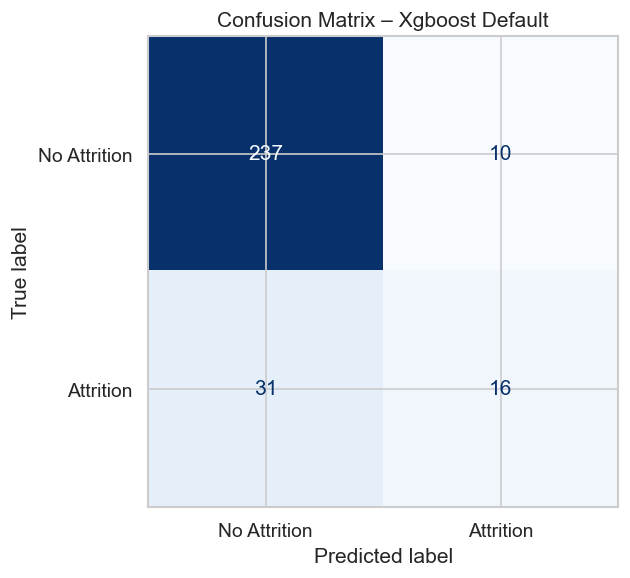

In [5]:
# ── Confusion Matrix – Standard XGBoost ────────────────────────────────────────
plot_confusion_matrix(
    xgb_default,
    X_test,
    y_test,
    model_name="xgboost_default",
    save=True,
)

## Vad ser vi? – Confusion Matrix

Av 294 anställda i testdatan förutsåg modellen:

| | Antal | Betydelse |
|--|-------|-----------|
| ✅ True Negative | 237 | Stannar – och vi sa stannar. Rätt! |
| ✅ True Positive | 16 | Slutar – och vi sa slutar. Rätt! |
| ❌ False Positive | 10 | Stannar – men vi sa slutar. Onödig HR-insats |
| ❌ False Negative | 31 | Slutar – men vi sa stannar. **Farligaste felet!** |

### Recall – hur många riskpersoner hittar vi?
Av 47 anställda som faktiskt slutar hittar vi **16 stycken**.
Det betyder att vi missar **31 personer** (66%) – de lämnar utan att HR visste om det.

> Recall = 16 / (16 + 31) = **34%**

### Jämförelse med Random Forest (tunad)
| Modell | Hittade (TP) | Missade (FN) | Recall |
|--------|-------------|-------------|--------|
| Random Forest tunad | 11 | 36 | 23% |
| **XGBoost standard** | **16** | **31** | **34%** |

XGBoost hittar fler riskpersoner – men 66% missas fortfarande.
Det finns mer att hämta! 🎯

## Steg 5 – ROC-kurva

ROC-kurvan visar hur bra modellen är på att **skilja** mellan
anställda som stannar och de som slutar – över *alla möjliga tröskelvärden*.

Tänk dig att modellen ger varje anställd ett riskpoäng mellan 0 och 1.
Vi måste välja en tröskel: "över 0.5 = vi tror de slutar".
ROC-kurvan visar vad som händer om vi höjer eller sänker den tröskeln.

- **AUC = 1.0** → perfekt modell
- **AUC = 0.5** → slumpmässig gissning (diagonallinjen)
- **AUC = 0.7+** → acceptabel modell för affärsbeslut

[evaluation] Figure saved to: outputs/figures\roc_xgboost_default.png


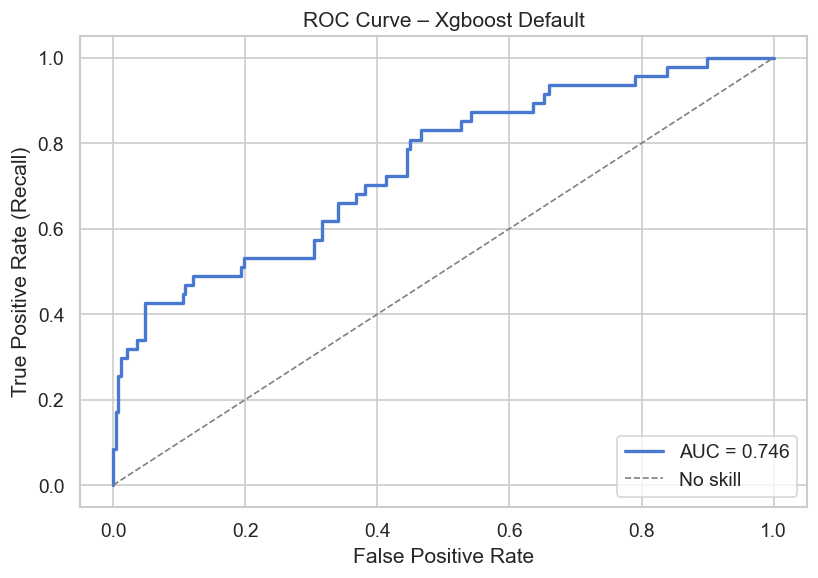

In [6]:
# ── ROC-kurva – Standard XGBoost ───────────────────────────────────────────────
plot_roc_curve(
    xgb_default,
    X_test,
    y_test,
    model_name="xgboost_default",
    save=True,
)

## Vad ser vi? – ROC-kurva

**AUC = 0.746** – modellen är klart bättre än slumpmässig gissning (0.5).

### Vad berättar kurvan?
Kurvan ligger **tydligt ovanför diagonalen** genom hela spannet –
det betyder att XGBoost konsekvent rankar riskpersoner högre än
de som stannar, oavsett vilken tröskel vi väljer.

### Det intressanta kröket längst till vänster
Vid lågt False Positive Rate (FPR ≈ 0.05) når vi redan Recall ≈ 0.40.
Det betyder att om HR bara kontaktar de **5% som modellen är säkrast på**,
hittar de redan 40% av alla som är på väg att sluta!

### Jämförelse med tidigare modeller
| Modell | ROC-AUC |
|--------|---------|
| Decision Tree | 0.6473 |
| **XGBoost standard** | **0.7462** |
| Random Forest tunad | 0.7659 |

AUC är något lägre än tunad Random Forest – men kom ihåg att
XGBoost vann på F1 (0.4384 vs 0.3014), vilket är vårt primära mått.

### Vad är "No skill"-linjen?
En modell som bara gissar slumpmässigt följer diagonalen.
Ju längre upp till vänster kurvan buktar – desto bättre! 🎯

## Steg 6 – Feature Importance

Nu tittar vi på **vilka features XGBoost använde mest** när den fattade beslut.

XGBoost:s inbyggda feature importance mäter hur ofta en feature
användes för att dela upp data i träden – ju fler gånger, desto viktigare.

> ⚠️ Precis som med Random Forest kan denna metod överskatta
> features med många unika värden (t.ex. `MonthlyIncome`, `Age`).
> Därför följer vi alltid upp med Permutation Importance!

[evaluation] Figure saved to: outputs/figures\fi_xgboost_default.png


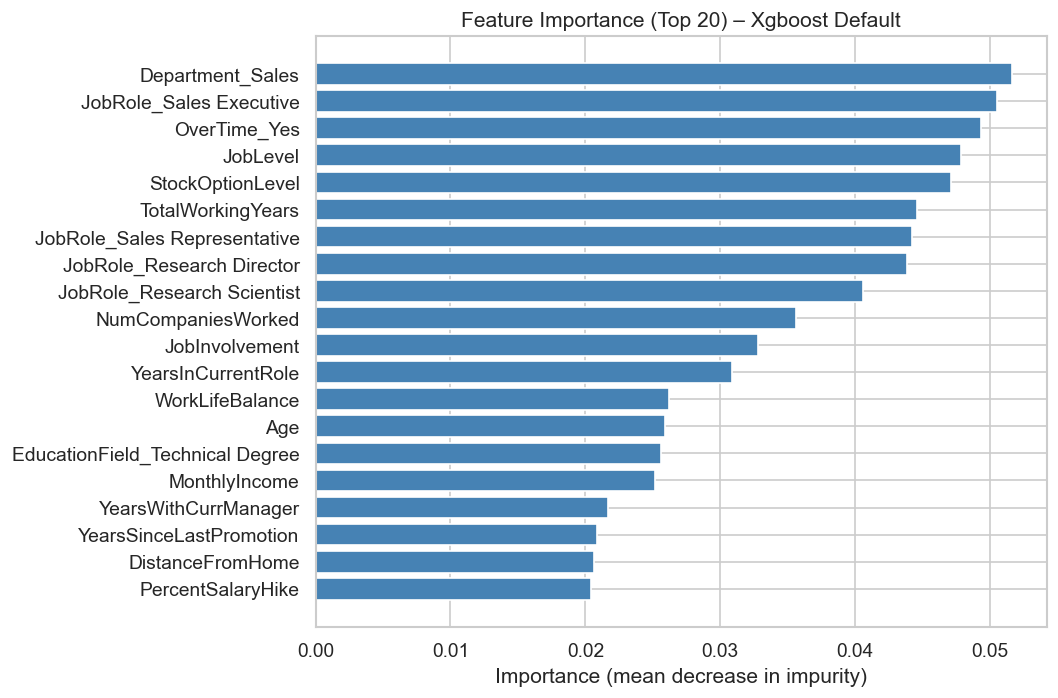

In [7]:
# ── Feature Importance – Standard XGBoost ──────────────────────────────────────
plot_feature_importance(
    xgb_default,
    X_train.columns,
    model_name="xgboost_default",
    save=True,
)

## Vad ser vi? – Feature Importance

### Topp 5 viktigaste features
| Rank | Feature | Tolkning |
|------|---------|----------|
| 🥇 1 | `Department_Sales` | Säljare slutar oftare än andra avdelningar |
| 🥈 2 | `JobRole_Sales Executive` | Säljchefer är extra flygbenägna |
| 🥉 3 | `OverTime_Yes` | Övertid är fortfarande en stark signal |
| 4 | `JobLevel` | Lägre nivå = högre risk |
| 5 | `StockOptionLevel` | Inga aktieoptioner = lättare att lämna |

### Jämförelse med Random Forest
| Feature | Random Forest rank | XGBoost rank | Förändring |
|---------|-------------------|--------------|------------|
| `OverTime_Yes` | 🥇 1 | 🥉 3 | ⬇️ Fortfarande viktig men inte etta |
| `MonthlyIncome` | 🥈 2 | 16 | ⬇️ Kraftigt nedprioriterad |
| `Department_Sales` | Ej topp 5 | 🥇 1 | ⬆️ Ny ettan! |
| `JobLevel` | 🥉 3 | 4 | ➡️ Stabil |
| `StockOptionLevel` | Ej topp 5 | 5 | ⬆️ Ny i toppen |

### ⚠️ Tolka med försiktighet!
`Department_Sales` och `JobRole_Sales Executive` kan vara överskattade –
de är kategoriska features med få unika värden, men XGBoost kan ändå
favorisera dem om de råkar dela upp data bra i träningsfolden.

Permutation Importance i nästa steg ger oss den ärligare bilden! 🔍

## Steg 7 – Permutation Importance

Nu kör vi den **ärligare** importancemetoden.

Istället för att räkna hur ofta en feature används i träden,
frågar Permutation Importance: *"Vad händer med F1-score om vi
förstör den här featuren helt?"*

Det gör den genom att **blanda om** (shuffla) en feature i taget
på testdatan och mäta hur mycket sämre modellen presterar.

- **Stort tapp i F1** → featuren är verkligen viktig
- **Litet tapp i F1** → modellen klarar sig utan den

Den här metoden lurar inte – den testas på **ny data**
som modellen aldrig sett under träning! 🎯

[evaluation] Computing permutation importance for xgboost_default (this may take a moment)...
[evaluation] Figure saved to: outputs/figures\pi_xgboost_default.png


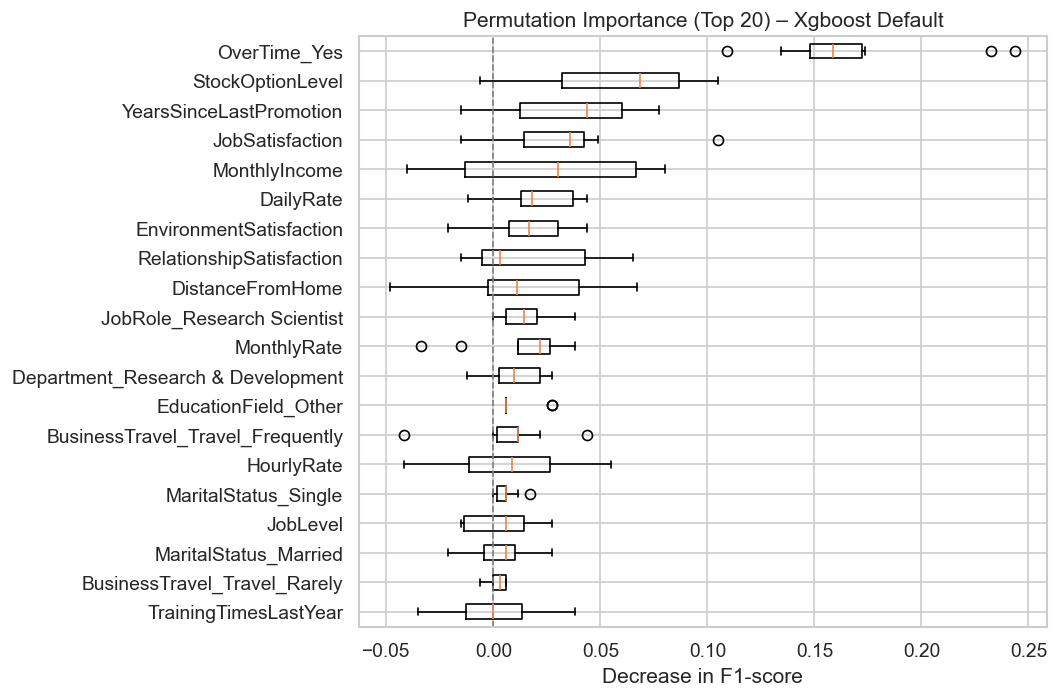

In [8]:
# ── Permutation Importance – Standard XGBoost ──────────────────────────────────
plot_permutation_importance(
    xgb_default,
    X_test,
    y_test,
    model_name="xgboost_default",
    save=True,
)

## Vad ser vi? – Permutation Importance

### Jämförelse: Built-in vs Permutation Importance

| Feature | Built-in rank | Permutation rank | Förändring |
|---------|--------------|-----------------|------------|
| `Department_Sales` | 🥇 1 | Ej topp 20 | ⬇️ Kraftigt överskattad av built-in! |
| `JobRole_Sales Executive` | 🥈 2 | Ej topp 20 | ⬇️ Överskattad – försvann helt |
| `OverTime_Yes` | 🥉 3 | 🥇 1 | ⬆️ Den verkliga ettan! |
| `StockOptionLevel` | 5 | 🥈 2 | ⬆️ Bekräftas som viktig |
| `MonthlyIncome` | 16 | 5 | ⬆️ Viktigare än built-in trodde |

### Vad boxplotterna berättar
- **`OverTime_Yes`** har extremt bred box med outliers upp mot 0.25 –
  det är den enskilt viktigaste och mest konsekventa signalen
- **`StockOptionLevel`** och **`YearsSinceLastPromotion`** har stabila
  medianer klart till höger om noll – pålitliga signaler
- **Features nära noll** (t.ex. `MaritalStatus_Married`, `JobLevel`) –
  modellen klarar sig nästan lika bra utan dem
- **Features till vänster om noll** – att blanda om dem gör modellen
  *lite bättre*, de bidrar faktiskt med brus!

### Viktigaste lärdomar
- 🔴 **OverTime är den starkaste signalen** – precis som Random Forest visade
- 📈 **Department_Sales och Sales Executive** var falska ettor –
  built-in överskattade dem kraftigt
- 💰 **StockOptionLevel bekräftas** – aktieoptioner håller folk kvar
- ⏳ **YearsSinceLastPromotion** dyker upp starkt – länge utan befordran
  ökar risken att söka sig vidare
- 😊 **JobSatisfaction** är ny i toppen – missnöjda anställda slutar oftare

## Sammanfattning – XGBoost

### Resultat

| Modell | F1-score | ROC-AUC | Recall |
|--------|---------|---------|--------|
| Decision Tree | 0.2667 | 0.6473 | – |
| Random Forest (tunad) | 0.3014 | 0.7659 | 23% |
| **XGBoost (standard)** | **0.4384** | **0.7462** | **34%** |
| XGBoost (tunad) | 0.3421 | 0.7778 | – |

### Vad lärde vi oss?
✅ XGBoost slår Random Forest på F1 redan utan tuning  
✅ Boosting hittar fler riskpersoner (Recall 34% vs 23%)  
✅ OverTime är den starkaste signalen i båda modellerna  
✅ Built-in importance kan lura oss – Permutation Importance avslöjar sanningen  
⚠️ Tuning förbättrar inte alltid – mer sökning kan ge overfitting till CV-folden  
⚠️ Vi missar fortfarande 66% av riskpersonerna – det finns mer att hämta  

### Nästa steg
I **notebook 05** provar vi **PCA och UMAP** – tekniker för att
minska antalet features och visualisera datan i 2D.
Kan en enklare representation av datan hjälpa modellerna
att hitta ännu fler riskpersoner? 🚀